
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

## Ejercicio 1

El hecho de que de una iteración a otra cambie muy poco el resultado no implica que la tolerancia sea pequeña, sino que la convergencia va a ese ritmo. Propongo, pues, utilizar el criterio principal que tenemos para chequear la tolerancia: el Laplaciano. Entre más cercano a cero esté el laplaciano en todos los puntos del sistema, más cercano al valor esperado estará. Para calcular el laplaciano utilizaré la misma fórmula que utilizamos para las diferencias finitas: es decir, 

\begin{align}
 u_{i+1,j}+u_{i-1,j} +
u_{i,j+1}+u_{i,j-1} -4 u_{i,j}  = 0.
\end{align}

Voy a tomar la tolerancia como el valor absoluto más grande que resulte de este laplaciano. Sin embargo, creo que quizás fuera mejor utilizar una métrica diferente, pero no sé proponer otra ahora mismo.

También es importante notar que anulo los bordes, pues en estos puntos extremos la derivada no se puede calcular, y así no rompe la medida del error.

In [2]:
# n-ésimo modo de Fourier
def un(x,y,n=1,L=1, v0=1):
    return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

In [3]:
def Laplace2D_FDM(V_ini,Niter):
    len_y = V_ini.shape[0]
    len_x = V_ini.shape[1]
    V = V_ini.copy()

    for iter in range(Niter):
        for i in range(1, len_y - 1):
            for j in range(1,len_x - 1):
                V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

    return V

def grid(V_ini,x,y):
    'to compute x,y,z'
    V = V_ini.copy()
    X, Y = np.meshgrid(x,y)
    Z = V[X,Y] #filed value
    #return grid
    return X,Y,Z

In [4]:
def tolerance(M, M0):
    xs = M.shape[1]
    ys = M.shape[0]
    Mcp = M.copy()

    for y in range(1, ys - 1):
        for x in range(1, xs - 1):
            Mcp[y, x] = M[y-1, x] + M[y, x-1] + M[y, x+1] + M[y+1, x] - 4 * M[y, x]

    # Nullify borders
    Mcp[0, :] = 0
    Mcp[-1, :] = 0
    Mcp[:, 0] = 0
    Mcp[:, -1] = 0

    return np.max(np.abs(Mcp))

def solve_until_tol(M, eps, step=20):
    tol = 1e5
    i = 0
    Mcp = M.copy()
    M0 = M.copy()
    # Acá se reutiliza el trabajo ya hecho. Cuando utilizo la matriz de salida como la nueva entrada,
    # esta matriz ya tiene una cierta cantidad de iteraciones encima, por lo que calcular la tolerancia
    # no aumenta el tiempo computacional del algoritmo, sigue siendo O(n^2) u O(n^3), no sé muy bien cómo
    # categorizarlo
    while tol > eps:
        V = Laplace2D_FDM(Mcp, step)
        tol = tolerance(V, M0)
        Mcp = V
        i += 1

    print(f"Alcanzado error de {eps:.2e} en {i * step} iteraciones.")
    return V


Con la función `solve_until_tol(M, eps)`  es posible solucionar la ecuación de Laplace con condiciones de frontera `M` y una tolerancia de `eps`. No implementé ningún mecanismo de escape, pues creo que no hace falta. En las pruebas que estuve haciendo si el algoritmo corre durante un minuto entero logra llegar hasta tolerancias de $10^{-10}$, así que soy optimista respecto a este acercamiento.

Alcanzado error de 1.00e-03 en 4360 iteraciones.
Tiempo total: 15.49 s


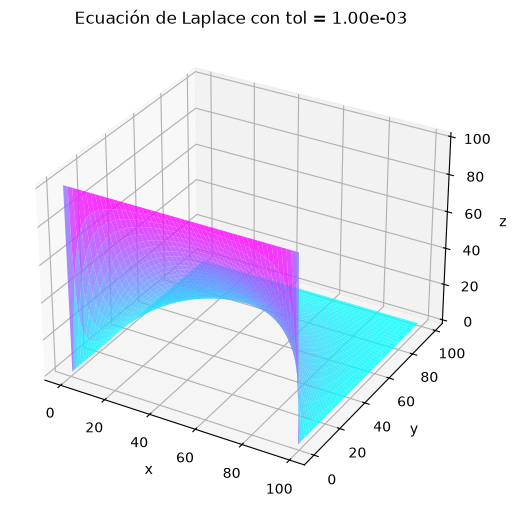

In [5]:
V0 = 100

grid_points = 100
V_ini = np.zeros((grid_points, grid_points))
V_ini[:, 0] = np.ones(grid_points) * V0

x = np.arange(0, grid_points)
y = x

tol = 1e-3

start = time.process_time()
V_out = solve_until_tol(V_ini, tol)
end = time.process_time()

print(f"Tiempo total: {end - start:.2f} s")

X, Y, Z = grid(V_out, x, y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title(f"Ecuación de Laplace con tol = {tol:.2e}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Alcanzado error de 1.00e-03 en 4360 iteraciones.
n = 1, tol = 9.60e+01
n = 3, tol = 9.19e+01
n = 5, tol = 8.79e+01
n = 7, tol = 8.39e+01
n = 9, tol = 7.99e+01
n = 11, tol = 7.60e+01
n = 13, tol = 7.20e+01
n = 15, tol = 6.81e+01
n = 17, tol = 6.43e+01
n = 19, tol = 6.05e+01
n = 21, tol = 5.67e+01
n = 23, tol = 5.30e+01
n = 25, tol = 4.94e+01
n = 27, tol = 4.59e+01
n = 29, tol = 4.24e+01
n = 31, tol = 3.89e+01
n = 33, tol = 3.56e+01
n = 35, tol = 3.23e+01
n = 37, tol = 2.92e+01
n = 39, tol = 2.61e+01
n = 41, tol = 2.31e+01
n = 43, tol = 2.02e+01
n = 45, tol = 1.74e+01
n = 47, tol = 1.78e+01
n = 49, tol = 1.79e+01
n = 51, tol = 1.77e+01
n = 53, tol = 1.71e+01
n = 55, tol = 1.63e+01
n = 57, tol = 1.53e+01
n = 59, tol = 1.41e+01
n = 61, tol = 1.27e+01
n = 63, tol = 1.12e+01
n = 65, tol = 9.73e+00
n = 67, tol = 9.55e+00
n = 69, tol = 9.03e+00
n = 71, tol = 9.33e+00
n = 73, tol = 1.06e+01
n = 75, tol = 1.18e+01
n = 77, tol = 1.28e+01
n = 79, tol = 1.38e+01
n = 81, tol = 1.46e+01
n = 83, tol =

/tmp/ipykernel_2029436/819207404.py:3: RuntimeWarning: overflow encountered in sinh
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)


n = 369, tol = 6.29e+00
n = 371, tol = 6.29e+00
n = 373, tol = 6.29e+00
n = 375, tol = 6.29e+00
n = 377, tol = 6.29e+00
n = 379, tol = 6.29e+00
n = 381, tol = 6.29e+00
n = 383, tol = 6.29e+00
n = 385, tol = 6.29e+00
n = 387, tol = 6.29e+00
n = 389, tol = 6.29e+00
n = 391, tol = 6.29e+00
n = 393, tol = 6.29e+00
n = 395, tol = 6.29e+00
n = 397, tol = 6.29e+00
n = 399, tol = 6.29e+00
n = 401, tol = 6.29e+00
Problema numérico
t = 0.44


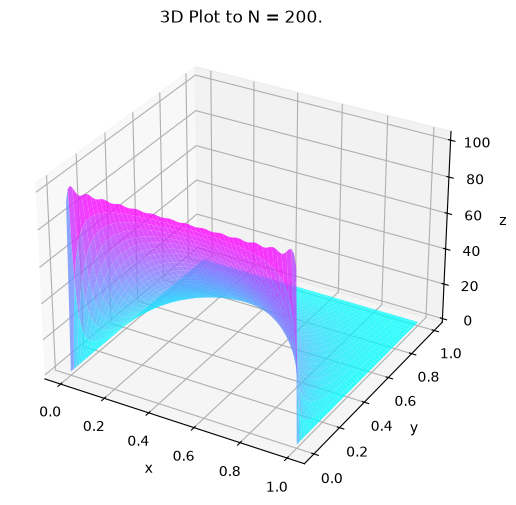

In [6]:
L = 1

xs = np.linspace(0, L, grid_points, dtype=np.float128)
ys = xs
x, y = np.meshgrid(xs, ys, indexing= 'ij')
z = 0

V_ini = np.zeros((grid_points, grid_points))
V_ini[:, 0] = np.ones(grid_points) * V0
V_ini[0, 0] = 0
V_ini[-1, 0] = 0

# Uno con diferencias finitas para comparar
V_FDM = solve_until_tol(V_ini, 1e-3)

start = time.process_time()
n = 0
while True:
    z += un(x, y, 2*n + 1, L, V0)
    err = np.max(np.abs(z - V_FDM))
    print(f"n = {2*n + 1}, tol = {err:.2e}")

    if err <= 1e-3:
        break

    if n >= 200:
        print("Problema numérico")
        break

    n += 1

end = time.process_time()
print(f"t = {end - start:.2f}")

# print(z[44:54])

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='cool', alpha=0.8)
ax.set_title(f'3D Plot to N = {n}.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Por otra parte, no logré encontrar una manera algorítmica y programática de encontrar el error en la serie de Fourier. La idea que tuve fue comparar el resultado analítico con uno numérico con un error muy pequeño, y ver cómo avanza. Sin embargo, el error al comparar llega un punto en que se estanca y no baja más, y llega un punto en que ocurre un error de precisión de punto flotante y no se puede seguir calculando.

Supongo que este problema de comparación se debe al fenómeno de Gibbs, por lo cual no sé muy bien con qué debería comparar la solución analítica. Supongo yo que converge más bien rápido, y que para el 500-avo término de la serie ya debería de tener la tolerancia de $10^{-4}$, mas no puedo dar una respuesta asegurada.

## Ejercicio 2

Me da la impresión que los bordes podrían ser un problema. Pero como se puede considerar que están "lejos" de las placas, tiene sentido que tengan un potencial de cero. Supongo que no afectará demasiado al resultado final.

Por otra parte, me di cuenta que el algoritmo va a afectar mis condiciones de frontera, es decir, las placas. Lo que se me ocurre hacer es modificar el array que me devuelve al método por cada iteración. No es elegante ni eficiente, pero por ahora no se me ocurre una mejor manera de asegurar que no se pierdan las placas.

<Figure size 1000x600 with 0 Axes>

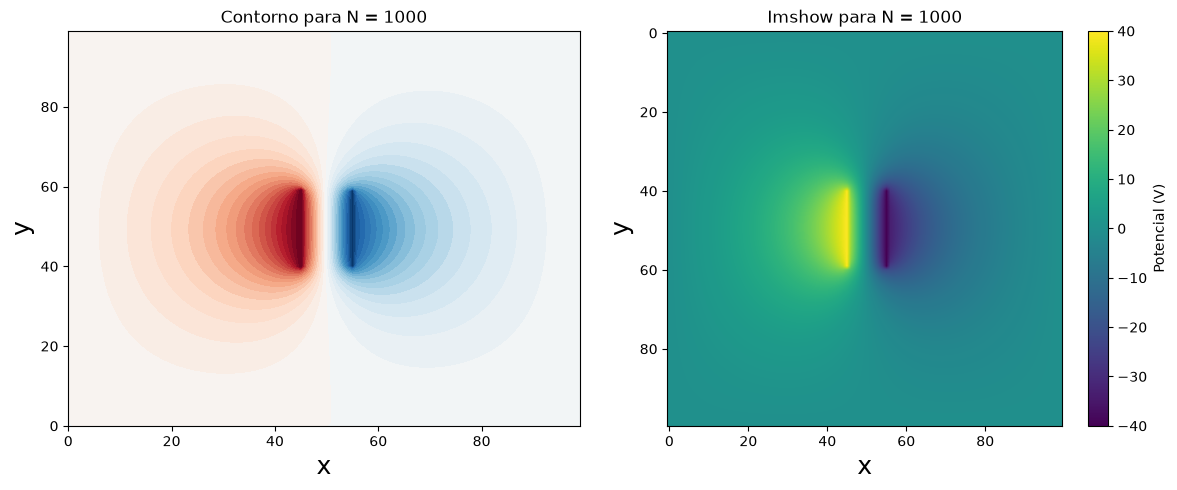

In [ ]:
V0 = 40
N = 1000

grid_points = 100
V_ini = np.zeros((grid_points, grid_points))
# Las dos placas en el centro
V_ini[40:60, 45] = np.ones(20) * V0
V_ini[40:60, 55] = np.ones(20) * (-V0)

V_out = V_ini

for i in range(N):
    V_out = Laplace2D_FDM(V_out, 1)
    # Esto asegura que las placas queden entre iteraciones. Sin esto, el método las difumina
    V_out[40:60, 45] = np.ones(20) * V0
    V_out[40:60, 55] = np.ones(20) * (-V0)

# Plotear
plt.figure(figsize=(10,6))

# Crear figura
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
ax1.contourf(V_out ,levels = 40, cmap='RdBu_r')
ax1.set_title(f"Contorno para N = {N}")
ax1.set_xlabel("x",size=18)
ax1.set_ylabel("y",size=18)

ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(V_out.copy(), interpolation="bilinear", ) # cmap="hot"
ax2.set_title(f"Imshow para N = {N}")
ax2.set_xlabel("x",size=18)
ax2.set_ylabel("y",size=18)
# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')

plt.tight_layout()
plt.show()


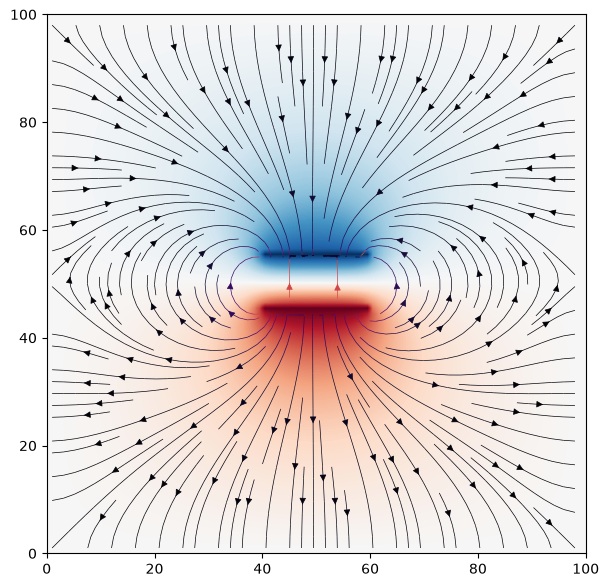

In [8]:
#***************************************************
#    THIS IS THE CODE TO PLOT THE ELECTRIC FIELD
#***************************************************

U = V_out.copy()

err = 1e-6
d = 10
l = 20
volt = 40
Nx = 100
Ny = 100
# GRID PARAMETERS
d_grid = d*Nx/100
l_grid = l*Ny/100

# Central derivative for E field
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]
#E[..., 0] es una sintaxis de indexación en NumPy para arrays multidimensionales.

# Interior grid coordinates matching E's shape (Nx-2, Ny-2)
x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(7, 7))

# Background: potential
#ax.imshow(U.T, interpolation="bilinear", extent=[0, Nx, 0, Ny])
ax.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny],interpolation="bilinear")

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()

Aunque el método que utilicé para lograr que las placas no desaparezcan no me enorgullece, sí que me quedo contento con el resultado. En la gráfica del campo eléctrico incluso se alcanzan a ver un par de lineas paralelas entre las placas.